# Assignment 1 - Fashion-MNIST Dense Network


## 1. 라이브러리 불러오기

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# GPU 사용 가능하면 GPU, 아니면 CPU 사용
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 중인 장치:', device)

사용 중인 장치: cuda


## 2. 데이터 불러오기 (Fashion-MNIST)

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # 픽셀값 정규화
])

train_dataset = datasets.FashionMNIST(root='./data', train=True,  download=True, transform=transform)
test_dataset  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

CLASSES = {0:'T-shirt/top', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
           5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle boot'}

print('학습 데이터 수:', len(train_dataset))
print('테스트 데이터 수:', len(test_dataset))

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.42MB/s]

학습 데이터 수: 60000
테스트 데이터 수: 10000


## 3. 모델 정의 (hidden layer 수 조절 가능)

In [3]:
# ── 기본 Dense Network (Baseline) ──────────────────────────────
class DenseNet(nn.Module):
    def __init__(self, num_hidden_layers=1):
        super(DenseNet, self).__init__()

        layers = [nn.Flatten()]  # 28x28 이미지를 784 벡터로 펼치기

        in_features = 784
        hidden_size = 256

        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            in_features = hidden_size

        layers.append(nn.Linear(in_features, 10))  # 출력층: 10개 클래스
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)


# ── 최적화 적용 Dense Network (BatchNorm + Dropout 추가) ────────
class OptimizedDenseNet(nn.Module):
    def __init__(self, num_hidden_layers=3):
        super(OptimizedDenseNet, self).__init__()

        layers = [nn.Flatten()]

        in_features = 784
        hidden_size = 256

        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.BatchNorm1d(hidden_size))  # Batch Normalization
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))              # Dropout (과적합 방지)
            in_features = hidden_size

        layers.append(nn.Linear(in_features, 10))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print('모델 정의 완료')

모델 정의 완료


## 4. 학습 및 평가 함수

In [4]:
def train(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct / len(loader.dataset)


def run_experiment(model, epochs=10, lr=0.001, use_adam=True):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr) if use_adam else optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    train_losses, test_accs = [], []
    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train(model, train_loader, optimizer, criterion)
        te_loss, te_acc = evaluate(model, test_loader, criterion)
        train_losses.append(tr_loss)
        test_accs.append(te_acc)
        print(f'Epoch {epoch:2d} | Train Loss: {tr_loss:.4f} | Test Acc: {te_acc*100:.2f}%')

    return train_losses, test_accs

print('함수 정의 완료')

함수 정의 완료


## 5. 실험 1 - Hidden Layer 수 비교 (1, 2, 3층)

In [5]:
results = {}

for n in [1, 2, 3]:
    print(f'\n=== Hidden Layer {n}개 ===' )
    model = DenseNet(num_hidden_layers=n)
    losses, accs = run_experiment(model, epochs=10)
    results[f'{n}-layer'] = {'losses': losses, 'accs': accs}
    print(f'최종 Test Accuracy: {accs[-1]*100:.2f}%')


=== Hidden Layer 1개 ===
Epoch  1 | Train Loss: 0.4852 | Test Acc: 84.96%
Epoch  2 | Train Loss: 0.3695 | Test Acc: 86.11%
Epoch  3 | Train Loss: 0.3332 | Test Acc: 86.52%
Epoch  4 | Train Loss: 0.3082 | Test Acc: 87.51%
Epoch  5 | Train Loss: 0.2891 | Test Acc: 86.53%
Epoch  6 | Train Loss: 0.2759 | Test Acc: 87.04%
Epoch  7 | Train Loss: 0.2597 | Test Acc: 87.91%
Epoch  8 | Train Loss: 0.2488 | Test Acc: 86.53%
Epoch  9 | Train Loss: 0.2374 | Test Acc: 88.19%
Epoch 10 | Train Loss: 0.2288 | Test Acc: 88.29%
최종 Test Accuracy: 88.29%

=== Hidden Layer 2개 ===
Epoch  1 | Train Loss: 0.4886 | Test Acc: 83.54%
Epoch  2 | Train Loss: 0.3669 | Test Acc: 85.27%
Epoch  3 | Train Loss: 0.3287 | Test Acc: 87.30%
Epoch  4 | Train Loss: 0.3030 | Test Acc: 87.06%
Epoch  5 | Train Loss: 0.2827 | Test Acc: 87.48%
Epoch  6 | Train Loss: 0.2654 | Test Acc: 87.14%
Epoch  7 | Train Loss: 0.2516 | Test Acc: 88.50%
Epoch  8 | Train Loss: 0.2404 | Test Acc: 88.14%
Epoch  9 | Train Loss: 0.2290 | Test Acc: 8

## 6. 실험 2 - 최적화 기법 적용 전/후 비교

In [7]:
print('=== Baseline (최적화 없음, 3 hidden layers) ===')
baseline = DenseNet(num_hidden_layers=3)
bl_losses, bl_accs = run_experiment(baseline, epochs=10)

print('\n=== Optimized (BatchNorm + Dropout + Adam) ===')
optimized = OptimizedDenseNet(num_hidden_layers=3)
op_losses, op_accs = run_experiment(optimized, epochs=10)

print(f'\nBaseline  최종 Accuracy: {bl_accs[-1]*100:.2f}%')
print(f'Optimized 최종 Accuracy: {op_accs[-1]*100:.2f}%')

=== Baseline (최적화 없음, 3 hidden layers) ===
Epoch  1 | Train Loss: 0.5059 | Test Acc: 83.79%
Epoch  2 | Train Loss: 0.3713 | Test Acc: 86.40%
Epoch  3 | Train Loss: 0.3368 | Test Acc: 86.14%
Epoch  4 | Train Loss: 0.3095 | Test Acc: 87.50%
Epoch  5 | Train Loss: 0.2913 | Test Acc: 87.60%
Epoch  6 | Train Loss: 0.2746 | Test Acc: 87.67%
Epoch  7 | Train Loss: 0.2591 | Test Acc: 87.74%
Epoch  8 | Train Loss: 0.2474 | Test Acc: 88.17%
Epoch  9 | Train Loss: 0.2349 | Test Acc: 88.06%
Epoch 10 | Train Loss: 0.2253 | Test Acc: 88.53%

=== Optimized (BatchNorm + Dropout + Adam) ===
Epoch  1 | Train Loss: 0.5339 | Test Acc: 84.73%
Epoch  2 | Train Loss: 0.4136 | Test Acc: 86.30%
Epoch  3 | Train Loss: 0.3812 | Test Acc: 86.69%
Epoch  4 | Train Loss: 0.3587 | Test Acc: 87.37%
Epoch  5 | Train Loss: 0.3399 | Test Acc: 86.81%
Epoch  6 | Train Loss: 0.3276 | Test Acc: 88.23%
Epoch  7 | Train Loss: 0.3180 | Test Acc: 88.19%
Epoch  8 | Train Loss: 0.3079 | Test Acc: 88.73%
Epoch  9 | Train Loss: 0.29

## 7. 결과 시각화

/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:25: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp

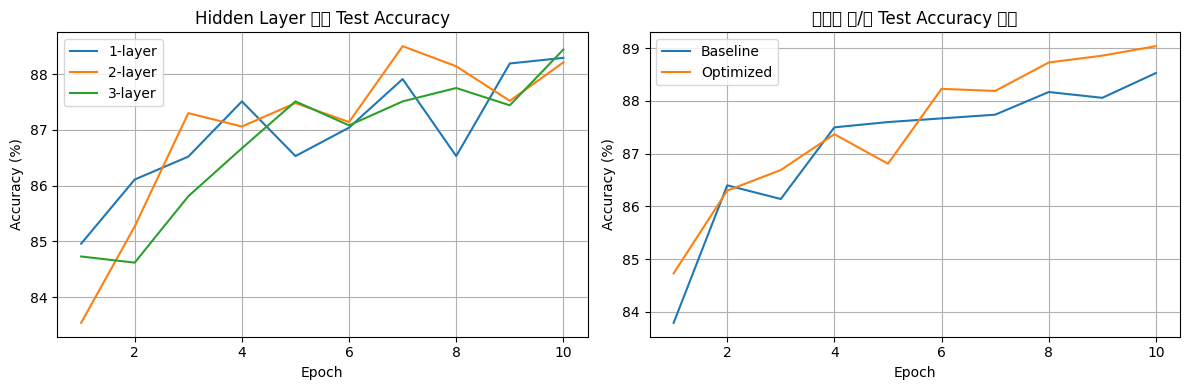

/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 54868 (\N{HANGUL SYLLABLE HWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_667/499392230.py:38: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/i

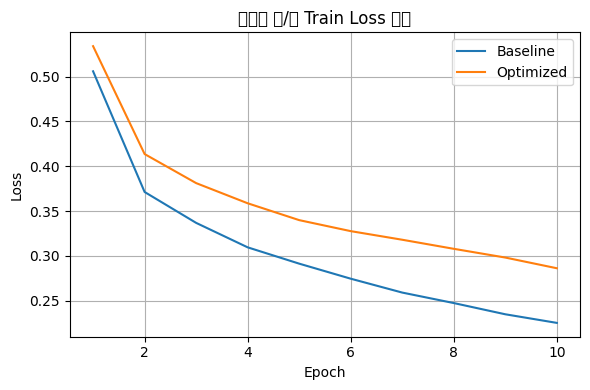

그래프 저장 완료


In [9]:
epochs = range(1, 11)

# 그래프 1: Hidden Layer 수별 accuracy 비교
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for key, val in results.items():
    plt.plot(epochs, [a*100 for a in val['accs']], label=key)
plt.title('Hidden Layer 수별 Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

# 그래프 2: 최적화 전/후 비교
plt.subplot(1, 2, 2)
plt.plot(epochs, [a*100 for a in bl_accs], label='Baseline')
plt.plot(epochs, [a*100 for a in op_accs], label='Optimized')
plt.title('최적화 전/후 Test Accuracy 비교')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('results.png', dpi=150)
plt.show()

# 그래프 3: 최적화 전/후 Loss 비교
plt.figure(figsize=(6, 4))
plt.plot(epochs, bl_losses, label='Baseline')
plt.plot(epochs, op_losses, label='Optimized')
plt.title('최적화 전/후 Train Loss 비교')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('loss_results.png', dpi=150)
plt.show()

print('그래프 저장 완료')